In [46]:
import pandas as pd
import os
import requests
from dotenv import load_dotenv
from datetime import datetime
import time
import json
from datetime import datetime
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import statistics
import numpy as np
import hdbscan
from sklearn.preprocessing import normalize

In [26]:

load_dotenv()
geneeaKey = os.environ["GENEEA_USER_KEY"]
print(geneeaKey)

4277eb27dc82dd4eb84e280bfc3eef1e


In [9]:
def callGeneea(input):
    url = 'https://api.geneea.com/v3/analysis'
    headers = {
        'content-type': 'application/json',
        'Authorization': 'user_key ' + geneeaKey
    }
    return requests.post(url, json=input, headers=headers).json()

In [5]:
trueData = pd.read_csv("True.csv")
fakeData = pd.read_csv("Fake.csv")

In [6]:
trueData["date"] = pd.to_datetime(trueData["date"], errors="coerce", format="mixed")
fakeData["date"] = pd.to_datetime(fakeData["date"], errors="coerce", format="mixed")

In [25]:
trueData.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29


In [30]:
try:
    with open("Geneea_Results_True.json") as f:
        trueGeneea = json.load(f)

except:
    trueGeneea = dict()

In [37]:
target = datetime.strptime("03/28/2017", "%m/%d/%Y")

targetData = trueData[((trueData["date"].dt.month == target.month)  & (trueData["date"].dt.year == target.year)) & (trueData["date"].dt.day == target.day)]

In [8]:
def getGroupWithAttr(targetData, attr=None, outputTitle="out.json"):
    try:
        with open(outputTitle) as f:
            geneeaOut = json.load(f)
    except FileNotFoundError:
        geneeaOut = dict()

    seen = set(geneeaOut.keys())
  
    for _, each in targetData.iterrows():
        title = each['title']
        if (title in seen):
            continue
        
        doc = callGeneea({"text": each['text'], "analyses": attr})
        if "exception" in doc:
            print(doc.get("exception"))
            break
        geneeaOut[title] = doc
        seen.add(title)
        with open(outputTitle, "w") as f:
            json.dump(geneeaOut, f)
        time.sleep(1)

def getGroup(targetData, outputTitle):
    getGroupWithAttr(targetData, ['entities', 'tags', 'relations', 'sentiment'], outputTitle)

In [ ]:
getGroup(targetData, "Geneea_Results_True.json")

In [142]:
loc_count = Counter()
for each in trueGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "location":
                loc_count[e["stdForm"]] += 1

print(loc_count.most_common(5))


[('United States of America', 408), ('WASHINGTON', 337), ('White House', 229), ('Washington', 94), ('Russia', 69)]


In [143]:
person_count = Counter()
for each in trueGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person":
                person_count[e["stdForm"]] += 1

print(person_count.most_common(5))

[('Donald Trump', 404), ('Barack Obama', 171), ('Obamacare', 59), ('Paul Ryan', 53), ('Rex Tillerson', 53)]


In [144]:
top5_people = {name for name, _ in person_count.most_common(5)}
person_count.most_common(5)

[('Donald Trump', 404),
 ('Barack Obama', 171),
 ('Obamacare', 59),
 ('Paul Ryan', 53),
 ('Rex Tillerson', 53)]

{'Barack Obama', 'Obamacare', 'Paul Ryan', 'Donald Trump', 'Rex Tillerson'}


Text(0, 0.5, 'Frequency')

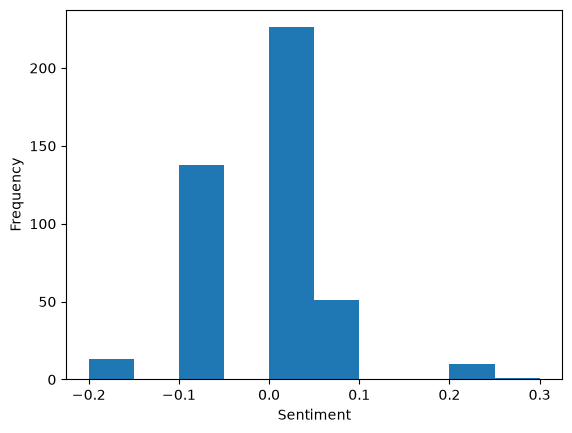

In [145]:
trueSent = []

for each in trueGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person" and e["stdForm"] in top5_people:
                trueSent.append(each.get("docSentiment").get("mean"))
                break


print(top5_people)
plt.hist(trueSent, bins=10)
plt.xlabel("Sentiment")
plt.ylabel("Frequency")

In [ ]:
target = datetime.strptime("03/2017", "%m/%Y")

targetData = trueData[((trueData["date"].dt.month == target.month)  & (trueData["date"].dt.year == target.year))]

getGroupWithAttr(targetData, ['entities', 'sentiment'], "Geneea_Results_True.json")

In [166]:
with open("Geneea_Results_True.json") as f:
    trueGeneea = json.load(f)

len(trueGeneea)

517

In [135]:
print('bisexual' in loc_count.keys())

False


In [191]:
def worstSent(data):
    worstSentiment = ("", 0)
    for key in data.keys():
        sent = data[key].get("docSentiment")
        if sent is None:
            continue
        sent = sent.get("mean")
        if sent < worstSentiment[1]:
            worstSentiment = (key, sent) 
    return worstSentiment

In [153]:
bestSentiment = ("", 0)
for key in trueGeneea.keys():
    sent = trueGeneea[key].get("docSentiment")
    if sent is None:
        continue
    sent = sent.get("mean")
    if sent > bestSentiment[1]:
       bestSentiment = (key, sent) 

print(bestSentiment)

('Lockheed Martin wins $582 million U.S. defense contract: Pentagon', 0.3)


In [165]:
worstSentiment = worstSent(trueGeneea)
doc = callGeneea({"text": trueData[trueData["title"] == worstSentiment[0]]["text"].iloc[0], "analyses": ['entities', 'tags', 'relations', 'sentiment']})

trueGeneea[worstSentiment[0]] = doc

with open("Geneea_Results_True.json", "w") as f:
    json.dump(trueGeneea, f)

In [180]:
relations = trueGeneea[worstSentiment[0]].get("relations")
rel_count = Counter()

for each in relations:
    rel_count[each.get("name")] +=1
print(rel_count)

Counter({'face': 5, 'pay': 3, 'former': 3, 'involve': 3, 'decline': 3, 'real estate': 2, 'say': 2, 'extend': 2, 'accuse': 2, 'take': 2, 'plea talk': 1, 'disclose': 1, 'seek': 1, 'that consider': 1, 'civil': 1, 'come': 1, 'substantial': 1, 'plead': 1, 'accept': 1, 'pursue': 1, 'one': 1, 'relate': 1, 'die': 1, 'await': 1, 'deputy': 1, 'have': 1, 'obtain': 1, 'back': 1, 'develop': 1, 'main': 1, 'evade': 1, 'conceal': 1, 'deny': 1, 'base': 1})


In [184]:
mostMentioned = {name for name, _ in rel_count.most_common(10)}
for each in relations:
    if each.get("name") in mostMentioned:
        print(each.get("textRepr") + "\n")

pay(bribes)

former(president)

real estate(billionaire estate developer)

say(lawyer)

extend(prosecutor)

involve(Jeff Yin)

extend(court deadline)

involve(tax assessment)

involve(liability)

could face(Jeff Yin,prison time)

face(he,bribery charge)

face(he,related)

face(he,money laundering)

decline(Sabrina Shroff,comment)

decline(comment)

former(President)

accuse(prosecutor,Ng)

accuse(prosecutor,Jeff Yin)

former(U.N. ambassador)

say(indictment)

pay(Ng,bribes)

take(ambassador,step)

face(charge)

pay(income taxes)

take(step)

real estate(estate developer)

decline(lawyer)



In [204]:
target = datetime.strptime("08/11/2016", "%d/%m/%Y")

targetDataFake = fakeData[fakeData["date"] == target]

In [206]:
getGroup(targetDataFake, "Geneea_Results_Fake.json")

In [207]:
with open("Geneea_Results_Fake.json") as f:
    fakeGeneea = json.load(f)

len(fakeGeneea)

21

In [208]:
worstSentiment = worstSent(fakeGeneea)
worstSentiment

(' Trump Tries To MANIPULATE Nevada Vote And Gets Shut Down HARD', -0.2)

[('Donald Trump', 13), ('Hillary Clinton', 11), ('Hillary', 5), ('Trump', 5), ('Obama', 4)]


Text(0, 0.5, 'Frequency')

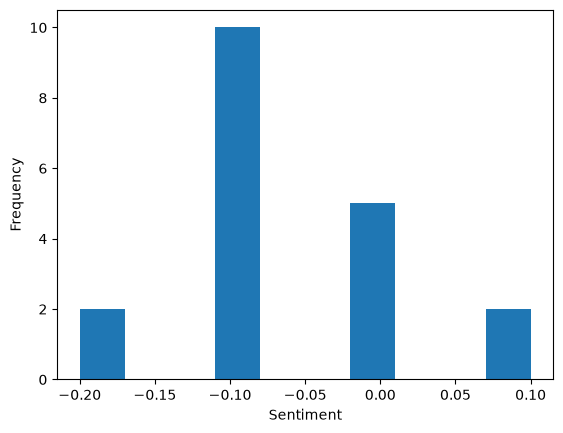

In [209]:
fake_person_count = Counter()

for each in fakeGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person":
                fake_person_count[e["stdForm"]] += 1

fakeTop5 = [name for name, _ in fake_person_count.most_common(5)]

fakeSent = []
for each in fakeGeneea.values():
    if "entities" in each:
        for e in each["entities"]:
            if e.get("type") == "person" and e["stdForm"] in fakeTop5:
                fakeSent.append(each.get("docSentiment").get("mean"))
                break


print(fake_person_count.most_common(5))
plt.hist(fakeSent, bins=10)
plt.xlabel("Sentiment")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

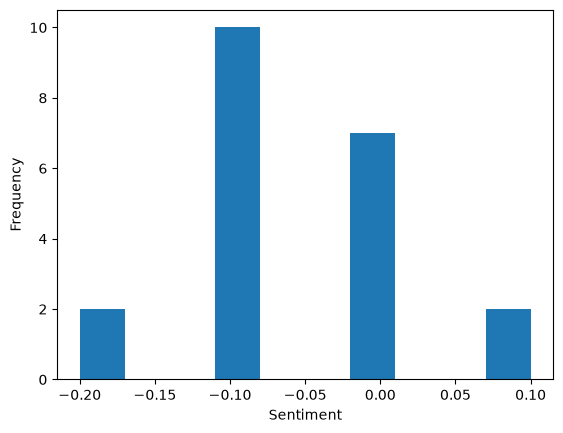

In [210]:
fakeSent = []
for each in fakeGeneea.values():
    fakeSent.append(each.get("docSentiment").get("mean"))


plt.hist(fakeSent, bins=10)
plt.xlabel("Sentiment")
plt.ylabel("Frequency")

In [211]:
relations = fakeGeneea[worstSentiment[0]].get("relations")
fake_rel_count = Counter()

for each in relations:
    fake_rel_count[each.get("name")] +=1
print(fake_rel_count)

Counter({'allow': 3, 'want': 3, 'close': 2, 'keep': 2, 'watch': 2, 'panic': 1, 'hold': 1, 'violate': 1, 'frivolous': 1, 'stay': 1, 'long': 1, 'try': 1, 'particular': 1, 'specific': 1, 'serve': 1, 'latino': 1, 'reject': 1, 'voice': 1, 'put': 1, 'reveal': 1, 'get': 1, 'order': 1, 'public': 1, 'harass': 1, 'civic': 1, 'use': 1, 'force': 1, 'preserve': 1, 'play': 1, 'honest': 1, 'start': 1, 'invalidate': 1, 'give': 1, 'terrify': 1, 'impending': 1, 'talk': 1, 'feature': 1, 'warped': 1})


In [212]:
mostMentioned = {name for name, _ in fake_rel_count.most_common(10)}
for each in relations:
    if each.get("name") in mostMentioned:
        print(each.get("textRepr") + "\n")

panic(Trump)

hold(rally)

violate(law)

allow(polling place)

frivolous(lawsuit)

allow(law,anyone)

close(poll)

stay(polling place)

want(he,record)

want(he,information)

want(he,keep)

keep(ballot)

allow(Cardenas market,people)

close(p.m.)

watch(you,Twitter)

watch(you,cable news show)

keep(which,record)



In [213]:
target = datetime.strptime("12/2017", "%m/%Y")

targetData = trueData[trueData["date"] >= target].head(100)
targetDataFake = fakeData[fakeData["date"] >= target].head(100)

getGroupWithAttr(targetData, ["tags", "sentiment"], "Compare_Geneea_Results_True.json")
print("done")
getGroupWithAttr(targetDataFake, ["tags", "sentiment"], "Compare_Geneea_Results_Fake.json")


done


In [28]:
with open("Compare_Geneea_Results_True.json") as f:
    compareTrue = json.load(f)
with open("Compare_Geneea_Results_Fake.json") as f:
    compareFake = json.load(f)

print(len(compareTrue))
print(len(compareFake))

100
100


In [31]:
def sentiment_by_tag(data):
    sentimentsPerTag = defaultdict(list)
    for each in data.values():
        sentiment = each.get("docSentiment")
        if sentiment is not None:
            sentiment = sentiment.get("mean")
            for tag in each.get("tags", []):
                sentimentsPerTag[tag.get("stdForm")].append(sentiment)
    return sentimentsPerTag

In [34]:
trueSents = sentiment_by_tag(compareTrue)
fakeSents = sentiment_by_tag(compareFake)

len(trueSents)

400

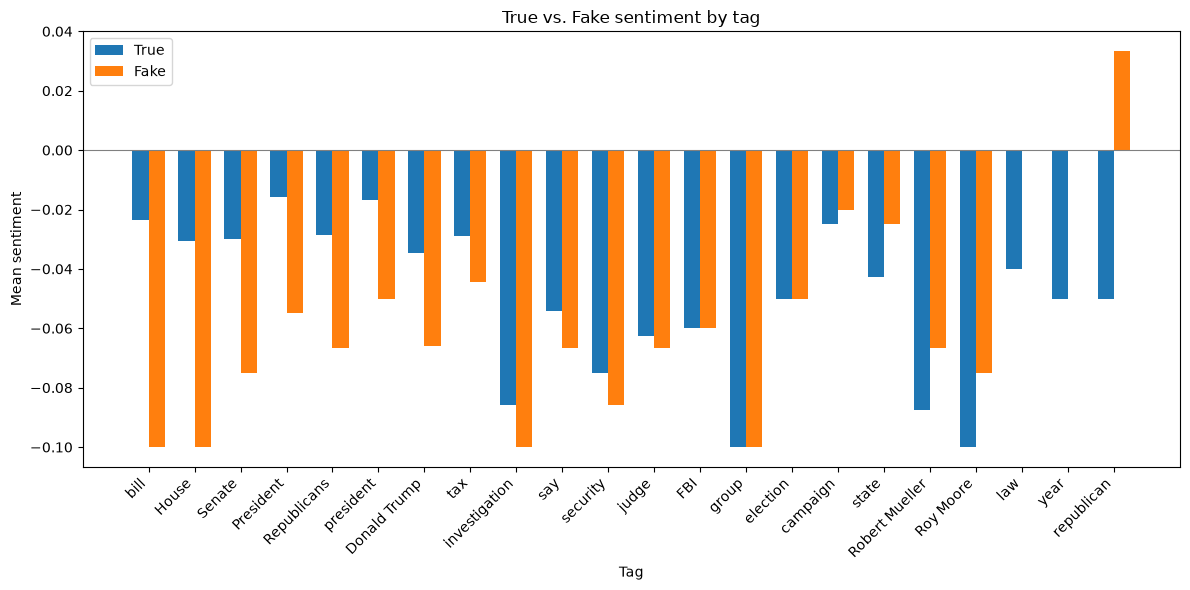

In [39]:
MIN = 3
tags = [t for t in set(trueSents) & set(fakeSents)
        if len(trueSents[t]) >= MIN and len(fakeSents[t]) >= MIN]

tags.sort(key=lambda t: statistics.mean(fakeSents[t]) - statistics.mean(trueSents[t]))

true_means = [statistics.mean(trueSents[t]) for t in tags]
fake_means = [statistics.mean(fakeSents[t]) for t in tags]

x = np.arange(len(tags))
width = 0.35     

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, true_means, width, label="True")
ax.bar(x + width/2, fake_means, width, label="Fake")

ax.set_xlabel("Tag")
ax.set_ylabel("Mean sentiment")
ax.set_title("True vs. Fake sentiment by tag")
ax.set_xticks(x)
ax.set_xticklabels(tags, rotation=45, ha="right")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

In [80]:
items = []

tagCount = Counter()

for article, isTrue in [(compareTrue, True), (compareFake, False)]:
        for title, r in article.items():
            tags = {t["stdForm"] for t in r.get("tags", [])
                        if t.get("type") == "base"}
            if tags:
                    items.append((title, tags, isTrue))
            for tag in tags:
                  tagCount[tag] += 1

vocab = sorted({tag for _, tags, _ in items for tag in tags if tagCount[tag]>1 and tag not in {name for name, _ in tagCount.most_common(4)}})

vocab_idx = {tag: i for i, tag in enumerate(vocab)}

X = np.zeros((len(items), len(vocab)))

for row, (_, tags, _) in enumerate(items):
    for tag in tags:
        if tag in vocab:
            X[row, vocab_idx[tag]] = 1  
print(X.shape)

(200, 250)


In [81]:
XNorm = normalize(X)
labels = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=1).fit_predict(XNorm)

print("clusters:", Counter(labels))                    
print("noise:", sum(labels == -1), "of", len(labels))

clusters: Counter({np.int64(-1): 89, np.int64(20): 18, np.int64(19): 11, np.int64(17): 9, np.int64(0): 8, np.int64(16): 5, np.int64(7): 5, np.int64(12): 5, np.int64(10): 5, np.int64(21): 5, np.int64(9): 4, np.int64(14): 3, np.int64(15): 3, np.int64(8): 3, np.int64(11): 3, np.int64(5): 3, np.int64(13): 3, np.int64(4): 3, np.int64(18): 3, np.int64(3): 3, np.int64(2): 3, np.int64(6): 3, np.int64(1): 3})
noise: 89 of 200


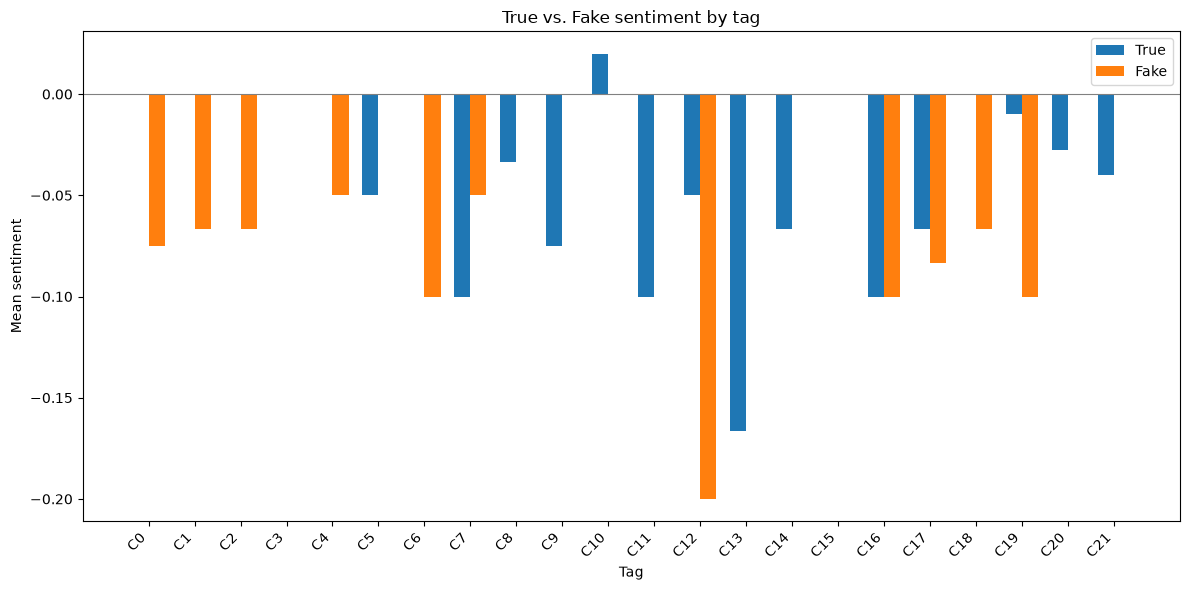

In [77]:
trueByCluster = defaultdict(list)
fakeByCluster = defaultdict(list)

for i in range(len(items)):
    if labels[i] != -1:
        (trueByCluster if items[i][2] else fakeByCluster)[labels[i]].append((compareTrue[items[i][0]] if items[i][2] else compareFake[items[i][0]]).get("docSentiment").get("mean"))



x = np.arange(len(set(trueByCluster.keys()) | set(fakeByCluster.keys())))
width = 0.35     

clusters = sorted(set(trueByCluster) | set(fakeByCluster))
trueMeans = [statistics.mean(trueByCluster[c]) if trueByCluster.get(c) else 0 for c in clusters]
fakeMeans = [statistics.mean(fakeByCluster[c]) if fakeByCluster.get(c) else 0 for c in clusters]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, trueMeans, width, label="True")
ax.bar(x + width/2, fakeMeans, width, label="Fake")

ax.set_xlabel("Tag")
ax.set_ylabel("Mean sentiment")
ax.set_title("True vs. Fake sentiment by tag")
ax.set_xticks(x)
ax.set_xticklabels([f"C{c}" for c in clusters], rotation=45, ha="right")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()